# Using Keras to classify handwritten digits Using MNIST Dataset

## 1. Prepare & Explore Dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
# import pachages 
from tensorflow import keras 
from keras.datasets import mnist 
from tensorflow.keras.models import Sequential 
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Activation, Flatten 
from tensorflow.keras.utils import to_categorical

In [3]:
# load the training and testing data. 
# (X_train, Y_train) are the training images and labels, 
# (X_test, Y_test) are the test images and labels

(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [4]:
X_train.shape, Y_train.shape

((60000, 28, 28), (60000,))

In [5]:
X_test.shape, Y_test.shape

((10000, 28, 28), (10000,))

In [6]:
# The labels indicate the value of the digit depicted in the images. 
# We want to convert this into a 10-entry encoded vector comprised of 0s and 1 in the entry corresponding to the digit. 
# For example, 4 is mapped to [0, 0, 0, 0, 1, 0, 0, 0, 0, 0] 
# Conversely, our network will have 10 output neurons

classes = 10 
Y_train = to_categorical(Y_train, classes)      
Y_test = to_categorical(Y_test, classes) 

## 2. Define the neural network architecture

In [7]:
epochs = 100

In [8]:
model = keras.Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(50, activation='sigmoid'))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(classes, activation='softmax'))

## 3. Compile the neural net

In [9]:
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='sgd')

In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 50)                39250     
                                                                 
 dense_1 (Dense)             (None, 100)               5100      
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 45,360
Trainable params: 45,360
Non-trainable params: 0
_________________________________________________________________


## 4. Fit / train the neural net

In [11]:
model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=epochs) 

Epoch 1/100
1875/1875 [==============================] - 8s 3ms/step - loss: 1.5858 - accuracy: 0.6747 - val_loss: 0.9824 - val_accuracy: 0.8270
Epoch 2/100
1875/1875 [==============================] - 6s 3ms/step - loss: 0.7274 - accuracy: 0.8571 - val_loss: 0.5535 - val_accuracy: 0.8793
Epoch 3/100
1875/1875 [==============================] - 7s 4ms/step - loss: 0.4891 - accuracy: 0.8839 - val_loss: 0.4317 - val_accuracy: 0.8943
Epoch 4/100
1875/1875 [==============================] - 7s 4ms/step - loss: 0.4140 - accuracy: 0.8934 - val_loss: 0.3841 - val_accuracy: 0.8985
Epoch 5/100
1875/1875 [==============================] - 6s 3ms/step - loss: 0.3744 - accuracy: 0.8989 - val_loss: 0.3565 - val_accuracy: 0.9043
Epoch 6/100
1875/1875 [==============================] - 7s 4ms/step - loss: 0.3533 - accuracy: 0.9013 - val_loss: 0.3390 - val_accuracy: 0.9041
Epoch 7/100
1875/1875 [==============================] - 6s 3ms/step - loss: 0.3351 - accuracy: 0.9050 - val_loss: 0.3188 - val_ac

1875/1875 [==============================] - 7s 4ms/step - loss: 0.2211 - accuracy: 0.9339 - val_loss: 0.2112 - val_accuracy: 0.9368
Epoch 58/100
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2158 - accuracy: 0.9344 - val_loss: 0.2162 - val_accuracy: 0.9361
Epoch 59/100
1875/1875 [==============================] - 8s 4ms/step - loss: 0.2147 - accuracy: 0.9355 - val_loss: 0.2309 - val_accuracy: 0.9294
Epoch 60/100
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2258 - accuracy: 0.9320 - val_loss: 0.2448 - val_accuracy: 0.9278
Epoch 61/100
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2166 - accuracy: 0.9352 - val_loss: 0.2121 - val_accuracy: 0.9344
Epoch 62/100
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2110 - accuracy: 0.9365 - val_loss: 0.2274 - val_accuracy: 0.9299
Epoch 63/100
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2137 - accuracy: 0.9352 - val_loss: 0.2099 - val_accuracy

## 5. Evaluate the neural net

In [12]:
score = model.evaluate(X_test, Y_test, verbose=1) 
print('Test accuracy:', score[1]) 

313/313 [==============================] - 1s 3ms/step - loss: 0.1971 - accuracy: 0.9381
Test accuracy: 0.9380999803543091


<hr>

# To see what the network has learned, we can visualize the weights of the hidden layer. 

In [15]:
weights = model.layers[1].get_weights() 

In [16]:
weights

[array([[ 0.01629744,  0.02466063, -0.02727027, ...,  0.01929213,
          0.04867277,  0.05757236],
        [ 0.0771971 ,  0.02710394, -0.02453056, ...,  0.05090653,
         -0.06315018,  0.03490182],
        [ 0.03381556,  0.00867485,  0.01528472, ..., -0.02452868,
         -0.00451744,  0.04107416],
        ...,
        [-0.07811663, -0.06729859,  0.00027011, ...,  0.0212554 ,
         -0.03097376,  0.05861462],
        [-0.00038242, -0.04241444, -0.06663841, ...,  0.03168865,
         -0.04373593, -0.07881543],
        [ 0.0660697 ,  0.0243848 ,  0.07016259, ...,  0.06873227,
          0.03013124,  0.03516837]], dtype=float32),
 array([ 7.0588512e-04,  8.0228731e-04, -4.1494789e-03,  6.4850168e-04,
         1.2993363e-03,  2.4620045e-03, -1.2024950e-03,  1.9780968e-03,
        -1.0411945e-03, -1.1366135e-03,  1.6830000e-04,  1.7782969e-03,
        -1.1515592e-03,  1.7680442e-03,  1.6568661e-04, -6.6445605e-04,
         4.9034163e-04,  1.1772524e-03, -3.1641871e-03,  8.0666159e-06

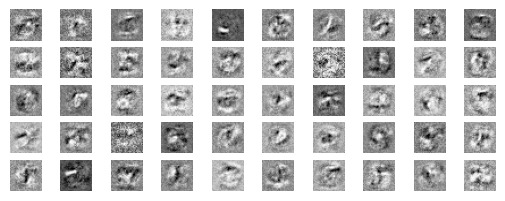

In [20]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy

hidden_neurons=50
fig = plt.figure()

w = weights[0].T
for neuron in range(hidden_neurons):
 ax = fig.add_subplot(10, 10, neuron + 1)
 ax.axis("off")
 ax.imshow(numpy.reshape(w[neuron], (28, 28)), cmap=cm.Greys_r)

plt.savefig("neuron_images.png", dpi=300)
plt.show()

<p> For simplicity, we've aggregated the images of all neurons in a single figure that represents a composite of all neurons. Clearly, since the initial images are very small and do not have lots of details (they are just digits), the features learned by the hidden neurons are not all that interesting. But it's already clear that each neuron is learning a different shape.

